# 01 — Problem Definition, Data Audit, and EDA

## Problem framing

**Given customer information available before churn, rank customers by churn risk and decide whom a retention campaign should target under limited resources.**

This is a **predictive churn modeling** problem: we learn a statistical association between customer attributes and subsequent churn, and use it to rank customers by risk.

Two things this project explicitly is **not**:

- It is **not a causal model**. The dataset contains no randomized retention treatment and no record of who was contacted by a retention campaign or what happened when they were. We cannot estimate the causal effect of an intervention (uplift / individual treatment effect) from this data — only correlations between customer attributes and churn.
- It is **not a claim that any campaign will work**. Section 4 of this project (retention decisioning) builds a transparent **scenario-based economic simulator** with explicit, labeled assumptions about cost, value, and success rate. Those assumptions are not observed in the data; they are inputs the business would supply, and the simulator shows how the recommended targeting policy changes as those inputs change.

## Dataset

Public **Telco Customer Churn** dataset (IBM/Kaggle), one row per customer, one snapshot in time, with a binary label for whether the customer churned.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
for d in (FIG_DIR, TABLE_DIR, PROCESSED_DIR):
    d.mkdir(parents=True, exist_ok=True)

## 1. Basic data audit

In [2]:
df_raw = data.load_raw()
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Audit finding — dataset size.** 7,043 customers, 21 columns (20 candidate features + target), one row per `customerID`, one static snapshot (no time series / no repeated observations per customer).

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


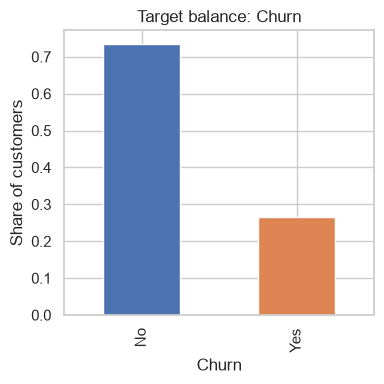

In [4]:
churn_balance = df_raw["Churn"].value_counts(normalize=True)
print(churn_balance)

fig, ax = plt.subplots(figsize=(4, 4))
churn_balance.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Target balance: Churn")
ax.set_ylabel("Share of customers")
fig.tight_layout()
fig.savefig(FIG_DIR / "target_balance.png", dpi=150)
plt.show()

**Audit finding — class balance.** Churn rate is ~26.5%. The positive class (churners) is a clear minority — this is why the project treats accuracy as a weak signal and prioritizes **PR-AUC and ranking metrics** (Recall@K, Precision@K, Lift@K) over threshold-free accuracy.

## 2. Missing values, duplicates, and identifier/leakage check

In [5]:
print("Missing values (raw dtypes):")
print(df_raw.isna().sum().sum(), "total nulls detected by isna() on raw columns")

# TotalCharges is read as an object/string column. Blank strings are not NaN,
# so isna() reports zero missing values here even though 11 rows cannot be
# parsed as numbers -- a hidden-missing-value trap worth flagging explicitly.
total_charges_numeric = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")
n_hidden_missing = total_charges_numeric.isna().sum()
print(f"Hidden missing values in TotalCharges (blank strings, not NaN): {n_hidden_missing}")

Missing values (raw dtypes):
0 total nulls detected by isna() on raw columns
Hidden missing values in TotalCharges (blank strings, not NaN): 11


In [6]:
blank_rows = df_raw.loc[total_charges_numeric.isna(), ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]
blank_rows

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


**Audit finding — TotalCharges parsing.** All 11 rows with unparseable `TotalCharges` have `tenure == 0`, i.e. brand-new customers who have not completed a billing cycle yet. We encode `TotalCharges = 0` for these rows rather than imputing a mean/median, because zero is the factually correct billed amount for a customer with no elapsed tenure — this is a data-entry/parsing gap, not a genuinely missing value. This logic is implemented once in `src/data.py::clean` and asserts the `tenure == 0` precondition so a future data refresh that breaks the assumption fails loudly instead of silently mis-imputing.

In [7]:
n_duplicate_rows = df_raw.duplicated().sum()
n_duplicate_ids = df_raw["customerID"].duplicated().sum()
print("Fully duplicated rows:", n_duplicate_rows)
print("Duplicated customerID values:", n_duplicate_ids)

Fully duplicated rows: 0
Duplicated customerID values: 0


**Audit finding — duplicates.** No duplicated rows and no duplicated `customerID` values. Each row is one unique customer.

**Audit finding — leakage variables.** `customerID` is a bare identifier with no predictive content and is dropped before modeling. No column in this dataset encodes post-outcome information (e.g. cancellation date, exit survey, retention-offer response) — the feature set describes customer state *before* the churn decision, consistent with the problem framing. There is therefore no obvious target-leakage column to remove beyond the identifier.

## 3. Feature types

In [8]:
df = data.clean(df_raw)
numeric_cols, categorical_cols = data.get_feature_columns(df)
print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)
print("Post-cleaning missing values:", df[numeric_cols + categorical_cols].isna().sum().sum())

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Post-cleaning missing values: 0


## 4. Distributions and churn-related differences (selective EDA)

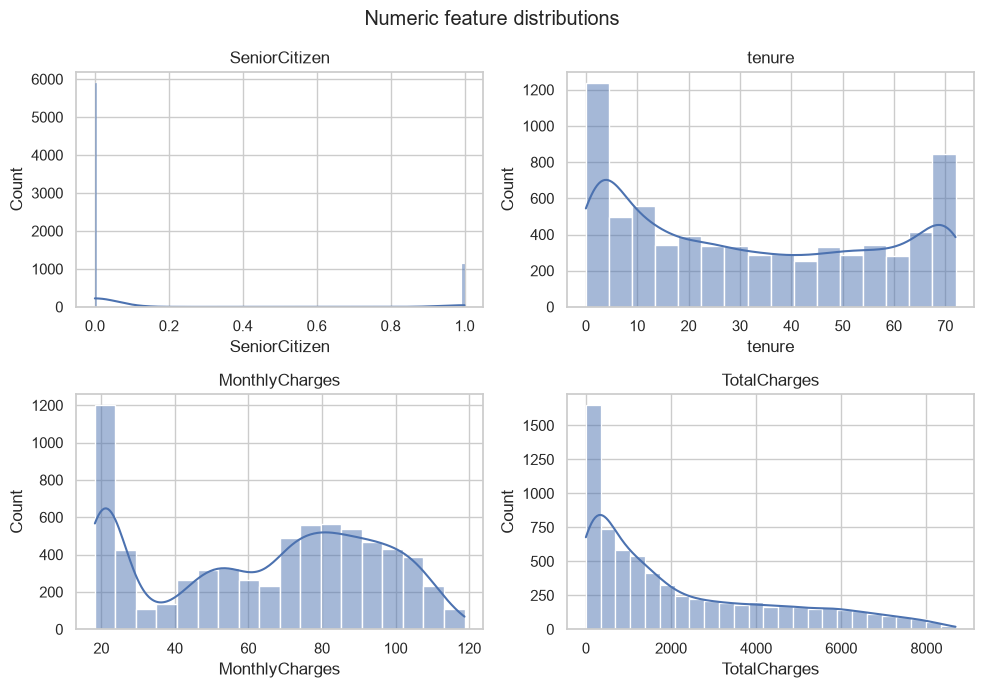

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
fig.suptitle("Numeric feature distributions")
fig.tight_layout()
fig.savefig(FIG_DIR / "numeric_distributions.png", dpi=150)
plt.show()

In [10]:
numeric_by_churn = df.groupby("Churn")[numeric_cols].mean().round(1)
numeric_by_churn.to_csv(TABLE_DIR / "numeric_features_by_churn.csv")
numeric_by_churn

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
Churn,,,,
No,0.1,37.6,61.3,2549.9
Yes,0.3,18.0,74.4,1531.8


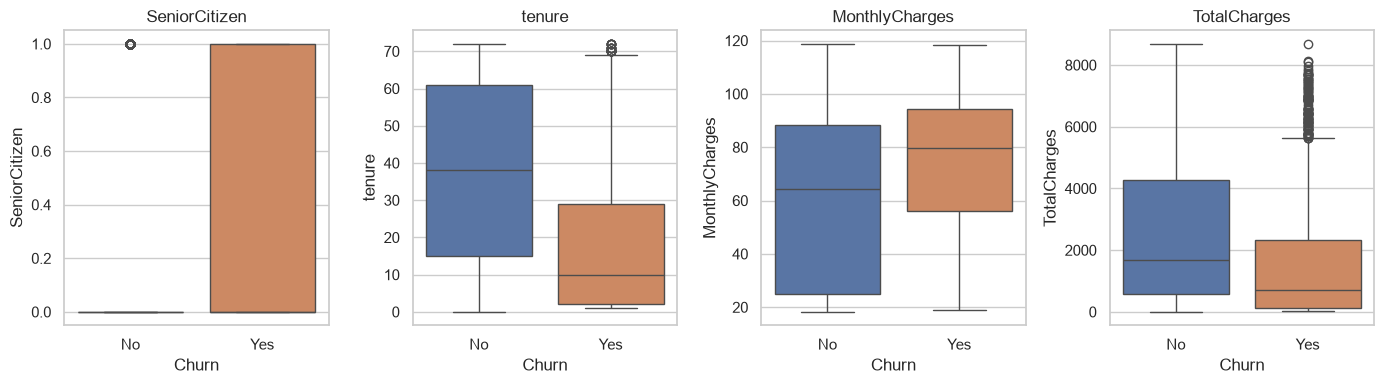

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x="Churn", y=col, hue="Churn", data=df, ax=ax, palette=["#4C72B0", "#DD8452"], legend=False)
    ax.set_title(col)
fig.tight_layout()
fig.savefig(FIG_DIR / "numeric_boxplots_by_churn.png", dpi=150)
plt.show()

**Finding.** Churners have, on average, much shorter tenure (18 vs. 38 months) and higher monthly charges (\$74 vs. \$61), and correspondingly lower total charges (a shorter relationship, not a cheaper one). `SeniorCitizen` is a 0/1 flag; its higher mean among churners (0.25 vs. 0.13) indicates senior citizens churn at roughly double the rate of non-seniors.

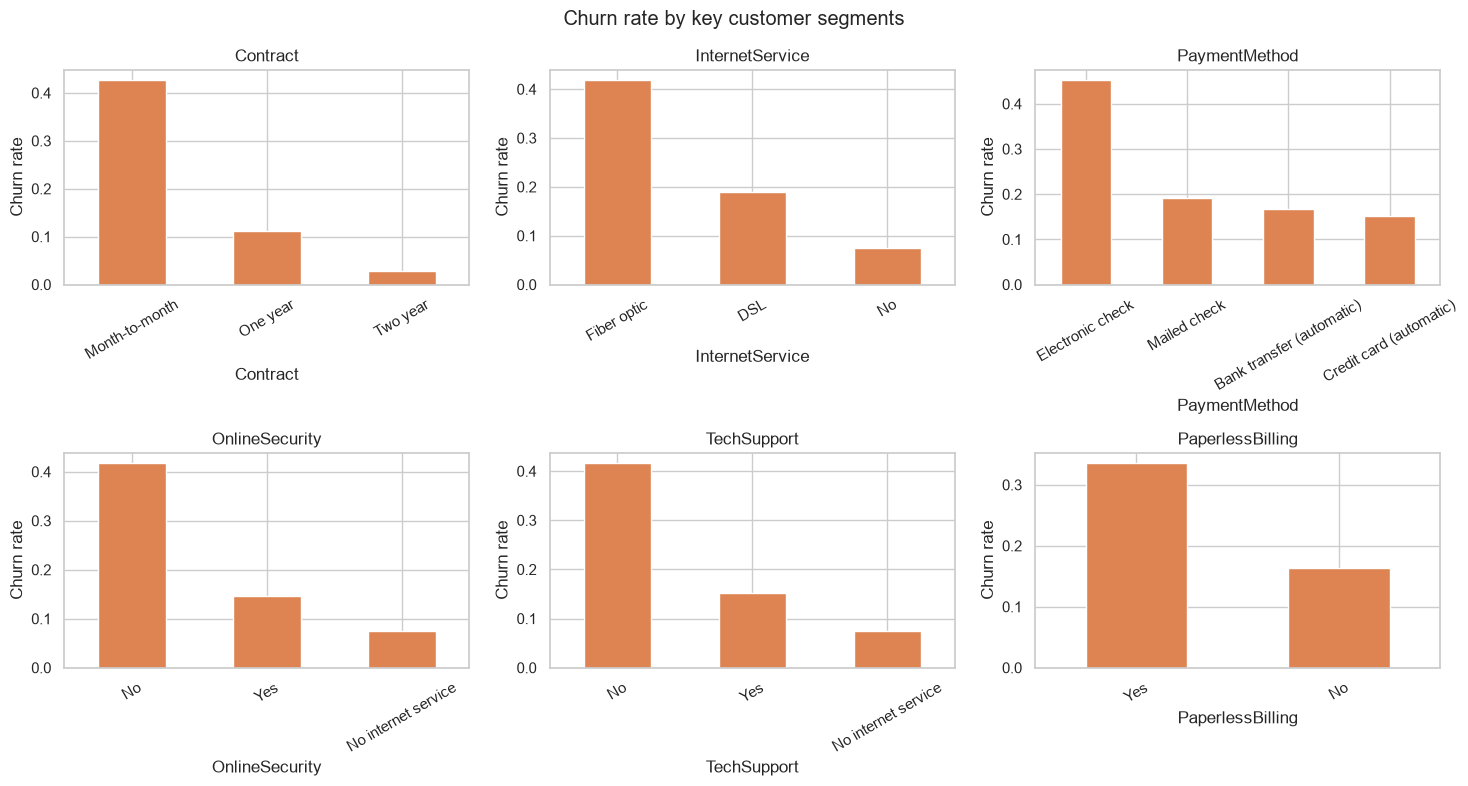

In [12]:
key_segments = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "PaperlessBilling"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), key_segments):
    rate = df.groupby(col)["churn_flag"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#DD8452")
    ax.set_title(col)
    ax.set_ylabel("Churn rate")
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Churn rate by key customer segments")
fig.tight_layout()
fig.savefig(FIG_DIR / "churn_rate_by_segment.png", dpi=150)
plt.show()

In [13]:
segment_churn_table = {}
for col in key_segments:
    segment_churn_table[col] = df.groupby(col)["churn_flag"].agg(["mean", "count"]).rename(
        columns={"mean": "churn_rate", "count": "n_customers"}
    )
    segment_churn_table[col].to_csv(TABLE_DIR / f"churn_rate_by_{col}.csv")

pd.concat(segment_churn_table, names=["segment", "value"])

churn_rate  n_customers
segment          value                                             
Contract         Month-to-month               0.427097         3875
                 One year                     0.112695         1473
                 Two year                     0.028319         1695
InternetService  DSL                          0.189591         2421
                 Fiber optic                  0.418928         3096
                 No                           0.074050         1526
PaymentMethod    Bank transfer (automatic)    0.167098         1544
                 Credit card (automatic)      0.152431         1522
                 Electronic check             0.452854         2365
                 Mailed check                 0.191067         1612
OnlineSecurity   No                           0.417667         3498
                 No internet service          0.074050         1526
                 Yes                          0.146112         2019
TechSupport      No                           0.416355         3473
                 No internet service          0.074050         1526
                 Yes                          0.151663         2044
PaperlessBilling No                           0.163301         2872
                 Yes                          0.335651         4171

**EDA findings that matter for modeling and retention:**

- **Contract type** shows the largest spread: month-to-month customers churn far more than one- or two-year contract holders. Contract is a strong, plausibly *actionable* lever (offering term commitments).
- **Fiber optic internet** customers churn more than DSL or no-internet customers — likely correlated with price and competitive intensity in that segment.
- **Electronic check** payers churn more than customers on automatic payment methods.
- **Lack of add-on services** (`OnlineSecurity`, `TechSupport` = "No") is associated with materially higher churn — these look like retention levers (bundling security/support) as much as risk indicators.
- **Paperless billing** correlates with higher churn — likely a proxy for a more price-sensitive, more digitally-engaged (and more likely to compare/switch) customer rather than a lever in itself.

These are **correlational** patterns from a single observational snapshot, not causal drivers — we return to this distinction explicitly in the segment diagnostics and explainability sections.

## 5. Freeze the train / validation / test split

The split happens exactly once, here, with a fixed seed, and is persisted to disk so every downstream notebook uses the identical partition. See `src/data.py::make_splits` for the implementation: a stratified 60/20/20 train/validation/test split. Test is written to disk and is not opened again until `03_final_test_evaluation.ipynb`.

In [14]:
splits = data.make_splits(df)
for name, part in splits.items():
    print(f"{name}: n={len(part)}, churn_rate={part['churn_flag'].mean():.4f}")
    part.to_csv(PROCESSED_DIR / f"{name}.csv", index=False)

print("\nSaved to", PROCESSED_DIR)

train: n=4225, churn_rate=0.2653
val: n=1409, churn_rate=0.2654
test: n=1409, churn_rate=0.2654

Saved to C:\Users\grosh\subscription-churn-model\data\processed


## Summary

- 7,043 customers, 20 candidate features, 26.5% churn rate — an imbalanced binary classification / ranking problem.
- One genuine data-quality issue found and fixed transparently: 11 blank `TotalCharges` values, all corresponding to zero-tenure customers, encoded as 0.
- No duplicates, no obvious leakage columns beyond the bare `customerID` identifier.
- Contract type, internet service, payment method, and add-on services (security/support) show the clearest churn differentials and are carried forward as candidate business levers.
- A stratified 60/20/20 train/validation/test split has been frozen and persisted; modeling and evaluation proceed in `02_modeling_and_validation.ipynb`.